# MESSAGEix-Pakistan 
## Run script for MESSAGE Pakistan model
   In this notebook, we are reading data and building baseline scenerios. Data was prepared in excel sheet, which we simply load and solve our model.

In [210]:
# Import required Libraries 
import pandas as pd
import ixmp
import message_ix
from message_ix import make_df
import os

# for modefiles execuation
import matplotlib.pyplot as plt
import pyam
import pandas as pd 
from ixmp import Platform
from ixmp.reporting import configure
from message_ix.reporting import Reporter
from pathlib import Path

# Import required files
from modelFiles.plotter_pakistan import plot, plotter

# Report Libraries
from message_ix.reporting import Reporter
#from modelFiles.update_units import unit_correction
from modelFiles.update_units_pakistan import unit_correction
import numpy as np

%matplotlib inline

In [211]:
# Loading Modeling platform
mp = ixmp.Platform()

In [212]:
# Creating a new, empty scenario
scenario = message_ix.Scenario(
    mp, model="Pakistan Model", scenario="baseline_xlsx", version="new"
)

While loading data, It's very important to pass aditional parameters like "init_items=True" in order to initialize items in a scenario with default values otherwise it will give some error.

In [213]:
# Add your project root folder path
root = os.chdir(r"C:\Users\umer.yasin\Desktop\NEST_Pakistan")
path = "data\data_MESSAGE_PK16.xlsx"

# Load data into our model - Current latest Data file is 
scenario.read_excel(path, add_units=True, commit_steps=False, init_items=True)

Cannot read set 'is_capacity_factor': index set(s) cannot be inferred for name(s) ['node_loc', 'year_act', 'year_vtg']


In [214]:
scenario.check_out()

In [147]:
scenario.par('demand')['commodity'].unique()

array(['i_feed', 'i_spec', 'i_therm', 'non-comm', 'rc_spec', 'rc_therm',
       'transport'], dtype=object)

In [148]:
df = scenario.par('demand')
# df2 = df[df['level'] == "secondary"]

In [149]:
lev = scenario.set('level')
lev

0       export
1        final
2      primary
3     resource
4    secondary
5       stocks
6       useful
7    renewable
dtype: object

In [88]:
# Get Unique technological names from output levewise
def get_unique_technology_names(lev , df):

    for i in lev:
        print(i)
        df2 = df[df['level'] == i]
        print(df2['technology'].unique())
        print(' ')


lev = scenario.set('level')
df = scenario.par('output')

get_unique_technology_names(lev , df)

export
['foil_exp' 'loil_exp' 'oil_exp' 'lh2_exp' 'meth_exp' 'elec_exp']
 
final
['biomass_t_d' 'coal_t_d' 'elec_t_d' 'eth_t_d' 'foil_t_d' 'gas_t_d'
 'gas_t_d_ch4' 'h2_t_d' 'heat_t_d' 'landfill_direct1' 'landfill_heatprdn'
 'lh2_t_d' 'loil_t_d' 'meth_t_d' 'h2_fc_trp']
 
primary
['HFCo_TCE' 'N2Oo_TCE' 'coal_extr' 'coal_extr_ch4' 'eth_bio' 'eth_bio_ccs'
 'gas_extr_1' 'gas_extr_2' 'gas_extr_3' 'gas_extr_4' 'gas_extr_5'
 'gas_extr_6' 'h2_liq' 'land_use_biomass' 'lfil_con' 'lignite_extr'
 'liq_bio' 'liq_bio_ccs' 'meth_coal' 'meth_coal_ccs' 'meth_ng'
 'meth_ng_ccs' 'oil_extr_1' 'oil_extr_1_ch4' 'oil_extr_2' 'oil_extr_2_ch4'
 'oil_extr_3' 'oil_extr_3_ch4' 'oil_extr_4' 'oil_extr_4_ch4' 'oil_extr_5'
 'oil_extr_6' 'oil_extr_7']
 
resource
[]
 
secondary
['LNG_bal' 'LNG_imp' 'LNG_regas' 'bco2_tr_dis' 'bio_extr_mpen' 'bio_hpl'
 'bio_istig' 'bio_istig_ccs' 'bio_ppl' 'bio_ppl_co2scr' 'c_ppl_co2scr'
 'cement_CO2' 'cement_co2scr' 'co2_tr_dis' 'coal_adv' 'coal_adv_ccs'
 'coal_bal' 'coal_gas' 'coal_imp'

In [79]:
df = scenario.par('output')
df2 = df[df['level'] == "secondary"]
df2['technology'].unique()

array(['LNG_bal', 'LNG_imp', 'LNG_regas', 'bco2_tr_dis', 'bio_extr_mpen',
       'bio_hpl', 'bio_istig', 'bio_istig_ccs', 'bio_ppl',
       'bio_ppl_co2scr', 'c_ppl_co2scr', 'cement_CO2', 'cement_co2scr',
       'co2_tr_dis', 'coal_adv', 'coal_adv_ccs', 'coal_bal', 'coal_gas',
       'coal_imp', 'coal_ppl', 'coal_ppl_u', 'csp_sm1_res',
       'csp_sm1_res1', 'csp_sm1_res2', 'csp_sm1_res3', 'csp_sm1_res4',
       'csp_sm1_res5', 'csp_sm1_res6', 'csp_sm1_res7', 'csp_sm3_res',
       'csp_sm3_res1', 'csp_sm3_res2', 'csp_sm3_res3', 'csp_sm3_res4',
       'csp_sm3_res5', 'csp_sm3_res6', 'csp_sm3_res7', 'eth_bal',
       'eth_bio', 'eth_bio_ccs', 'eth_imp', 'flaring_CO2', 'foil_imp',
       'foil_ppl', 'g_ppl_co2scr', 'gas_bal', 'gas_bio', 'gas_cc',
       'gas_cc_ccs', 'gas_ct', 'gas_extr_mpen', 'gas_hpl', 'gas_imp',
       'gas_ppl', 'geo_hpl', 'geo_ppl', 'h2_bio', 'h2_bio_ccs', 'h2_coal',
       'h2_coal_ccs', 'h2_elec', 'h2_mix', 'h2_smr', 'h2_smr_ccs',
       'hydro_hc', 'hydro_lc', 'ig

In [101]:
df = scenario.par('output')
df2 = df[df['level'] == "export"]
df2

,node_loc,technology,year_vtg,year_act,mode,node_dest,commodity,level,time,time_dest,value,unit
7459,Pakistan,foil_exp,1990,1990,M1,World,fueloil,export,year,year,1.0,GWa
7460,Pakistan,foil_exp,1990,1995,M1,World,fueloil,export,year,year,1.0,GWa
7461,Pakistan,foil_exp,1990,2000,M1,World,fueloil,export,year,year,1.0,GWa
7462,Pakistan,foil_exp,1990,2005,M1,World,fueloil,export,year,year,1.0,GWa
7463,Pakistan,foil_exp,1990,2010,M1,World,fueloil,export,year,year,1.0,GWa
...,...,...,...,...,...,...,...,...,...,...,...,...
10506,Pakistan,elec_exp,2060,2060,M1,World,electr_asia,export,year,year,1.0,GWa
10522,Pakistan,oil_exp,1995,2020,M1,World,crudeoil,export,year,year,1.0,GWa
10523,Pakistan,oil_exp,2005,2030,M1,World,crudeoil,export,year,year,1.0,GWa
10524,Pakistan,oil_exp,2000,2025,M1,World,crudeoil,export,year,year,1.0,GWa


In [95]:
df = scenario.par('output')
df2 = df[df['commodity'] == "fueloil"]
df2['technology'].unique()

array(['foil_imp', 'foil_t_d', 'ref_hil', 'ref_lol', 'foil_exp'],
      dtype=object)

In [108]:
df = scenario.par('output')
df2 = df[df['commodity'] == "transport"]
df2['technology'].unique()

array(['coal_trp', 'elec_trp', 'eth_fc_trp', 'eth_ic_trp', 'foil_trp',
       'gas_trp', 'loil_trp', 'meth_fc_trp', 'meth_ic_trp', 'h2_fc_trp'],
      dtype=object)

In [97]:
df = scenario.par('input')
df2 = df[df['level'] == "fueloil"]
df2

,node_loc,technology,year_vtg,year_act,mode,node_origin,commodity,level,time,time_origin,value,unit
1254,Pakistan,foil_i,1990,1990,M1,Pakistan,fueloil,final,year,year,1.818182,GWa
1255,Pakistan,foil_i,1990,1995,M1,Pakistan,fueloil,final,year,year,1.818182,GWa
1256,Pakistan,foil_i,1990,2000,M1,Pakistan,fueloil,final,year,year,1.818182,GWa
1257,Pakistan,foil_i,1990,2005,M1,Pakistan,fueloil,final,year,year,1.754386,GWa
1258,Pakistan,foil_i,1990,2010,M1,Pakistan,fueloil,final,year,year,1.724138,GWa
...,...,...,...,...,...,...,...,...,...,...,...,...
5780,Pakistan,foil_ppl,1960,2005,M1,Pakistan,fueloil,secondary,year,year,2.680965,GWa
5781,Pakistan,foil_ppl,1960,2010,M1,Pakistan,fueloil,secondary,year,year,2.564103,GWa
5782,Pakistan,foil_ppl,1960,2015,M1,Pakistan,fueloil,secondary,year,year,2.532051,GWa
5783,Pakistan,foil_ppl,1960,2020,M1,Pakistan,fueloil,secondary,year,year,2.500000,GWa


In [69]:
scenario.set('level')

0       export
1        final
2      primary
3     resource
4    secondary
5       stocks
6       useful
7    renewable
dtype: object

In [68]:
scenario.set('commodity')

0               LNG
1           biomass
2              coal
3           crude_1
4           crude_2
5           crude_3
6           crude_4
7           crude_5
8           crude_6
9           crude_7
10         crudeoil
11           d_heat
12           dumagr
13           electr
14      electr_asia
15          ethanol
16          exports
17          fueloil
18              gas
19            gas_1
20            gas_2
21            gas_3
22            gas_4
23            gas_5
24            gas_6
25         hydrogen
26           i_feed
27           i_spec
28          i_therm
29              lh2
30         lightoil
31          lignite
32         methanol
33         non-comm
34              puq
35          rc_spec
36         rc_therm
37        transport
38               u5
39              u5q
40               uq
41            gas_7
42          uranium
43            hydro
44             wind
45         solar_pv
46     wind_onshore
47    wind_offshore
dtype: object

In [55]:
# Check all parameters
def check_parameters(technology, parameters):
    # loop over the all parameters to get technologies values
    for i in parameters:
        df = scenario.par(i)
        # To check if parameters have relevent technology values
        if df.empty:
            print(i + " Not Found in Model")
            print('')
        elif df[df['technology'] == technology].empty:
            print( technology + ' Not Found in ' + i)
            print('')
        else:
            print(i)
            print(df[df['technology'] == technology])
            print('')

# Add Technology for which you want to get all parameters values
technology = "foil_imp"
# In order to check all par on filtered technology
#par = scenario.par_list()
# define own filterd parameters to get values
par2 = ['initial_activity_up', 'bound_activity_lo', 'growth_activity_lo', 'abs_cost_activity_soft_lo'
               , 'abs_cost_activity_soft_up', 'soft_activity_lo', 'level_cost_activity_soft_lo', 'initial_activity_lo',
               'initial_new_capacity_lo', 'initial_new_capacity_up' , 'level_cost_activity_soft_up', 'level_cost_new_capacity_soft_up',
               'relation_new_capacity', 'relation_activity', 'relation_total_capacity', 'soft_activity_up', 'soft_new_capacity_up', 
               'growth_activity_up', 'bound_activity_up', 'growth_new_capacity_lo', 
               'growth_new_capacity_up', 'historical_activity', 'historical_new_capacity']

check_parameters(technology, par2)        

foil_imp Not Found in initial_activity_up

bound_activity_lo
     node_loc technology  year_act mode  time  value unit
375  Pakistan   foil_imp      2020    P  year    8.9  GWa

growth_activity_lo
     node_loc technology  year_act  time  value unit
180  Pakistan   foil_imp      1995  year  -0.05    -
181  Pakistan   foil_imp      2000  year  -0.05    -
182  Pakistan   foil_imp      2005  year  -0.05    -
183  Pakistan   foil_imp      2010  year  -0.05    -
184  Pakistan   foil_imp      2020  year  -0.05    -
185  Pakistan   foil_imp      2030  year  -0.05    -
186  Pakistan   foil_imp      2040  year  -0.05    -
187  Pakistan   foil_imp      2050  year  -0.05    -
188  Pakistan   foil_imp      2060  year  -0.05    -
189  Pakistan   foil_imp      2025  year  -0.05    -
190  Pakistan   foil_imp      2035  year  -0.05    -
191  Pakistan   foil_imp      2045  year  -0.05    -
192  Pakistan   foil_imp      2055  year  -0.05    -

abs_cost_activity_soft_lo
    node_loc technology  year_act 

In [ ]:
scenario.par()

In [114]:
scenario.check_out()

In [6]:
scenario.par('initial_activity_up')

,node_loc,technology,year_act,time,value,unit
0,Pakistan,LNG_imp,2010,year,3.0,GWa/a
1,Pakistan,LNG_imp,2020,year,3.0,GWa/a
2,Pakistan,LNG_imp,2030,year,3.0,GWa/a
3,Pakistan,LNG_imp,2040,year,3.0,GWa/a
4,Pakistan,LNG_imp,2050,year,3.0,GWa/a
...,...,...,...,...,...,...
1074,Pakistan,elec_imp,2025,year,2.0,GWa/a
1075,Pakistan,elec_imp,2035,year,2.0,GWa/a
1076,Pakistan,elec_imp,2045,year,2.0,GWa/a
1077,Pakistan,elec_imp,2055,year,2.0,GWa/a


In [7]:
intial_act_up = scenario.par('initial_activity_up')

In [151]:
scenario.check_out()

In [152]:
intial_act_up = intial_act_up.loc[intial_act_up["technology"] =='foil_imp']
scenario.remove_par('initial_activity_up', intial_act_up)
scenario.par('initial_activity_up')

,node_loc,technology,year_act,time,value,unit
0,Pakistan,LNG_imp,2010,year,3.0,GWa/a
1,Pakistan,LNG_imp,2020,year,3.0,GWa/a
2,Pakistan,LNG_imp,2030,year,3.0,GWa/a
3,Pakistan,LNG_imp,2040,year,3.0,GWa/a
4,Pakistan,LNG_imp,2050,year,3.0,GWa/a
...,...,...,...,...,...,...
1061,Pakistan,elec_imp,2025,year,2.0,GWa/a
1062,Pakistan,elec_imp,2035,year,2.0,GWa/a
1063,Pakistan,elec_imp,2045,year,2.0,GWa/a
1064,Pakistan,elec_imp,2055,year,2.0,GWa/a


In [200]:
scenario.check_out()

In [201]:
df = make_df('bound_activity_lo',
                     node_loc = 'Pakistan', 
                     technology = 'foil_imp', 
                      year_act = 2020, 
                      mode = 'P',  
                      time = 'year', 
                      value = 8.9, 
                      unit = 'GWa')

scenario.add_par('bound_activity_lo', df)

In [185]:
scenario.check_out()

In [ ]:
# df = make_df('initial_activity_lo',
#                      node_loc = 'Pakistan', 
#                      technology = 'foil_imp', 
#                       year_act = 2020, 
#                       mode = 'P',  
#                       time = 'year', 
#                       value = 8.9, 
#                       unit = 'GWa/a')

# scenario.add_par('initial_activity_lo', df)

In [202]:
df = scenario.par('growth_activity_lo')
df2 = df[df['technology'] == "foil_imp"]
df2.loc[:, ('value')] = -0.05
scenario.add_par('growth_activity_lo', df2)
df3 = scenario.par('growth_activity_lo')
df3[df3['technology'] == "foil_imp"]

C:\Users\umer.yasin\AppData\Local\Temp\ipykernel_12960\2165462931.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.loc[:, ('value')] = -0.05


,node_loc,technology,year_act,time,value,unit
180,Pakistan,foil_imp,1995,year,-0.05,-
181,Pakistan,foil_imp,2000,year,-0.05,-
182,Pakistan,foil_imp,2005,year,-0.05,-
183,Pakistan,foil_imp,2010,year,-0.05,-
184,Pakistan,foil_imp,2020,year,-0.05,-
185,Pakistan,foil_imp,2030,year,-0.05,-
186,Pakistan,foil_imp,2040,year,-0.05,-
187,Pakistan,foil_imp,2050,year,-0.05,-
188,Pakistan,foil_imp,2060,year,-0.05,-
189,Pakistan,foil_imp,2025,year,-0.05,-


In [160]:
scenario.remove_solution()

In [170]:
scenario.check_out()

#### Correct Units
We use unit_correction function from modelFiles/update_units

In [ ]:
unit_correct = True  # unit s must be corrected to run this script

if unit_correct:
    unit_correction(mp, scenario)
# #     # caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)
# #     # Solving the model
# #     #scenario.solve(model='MESSAGE', case=caseName, solve_options={'lpmethod': '4'})

In [ ]:
# # Save unit-corrected scenario to new excel sheet
scenario.to_excel('data/MESSAGE_PAK__test__v6.xlsx')

In [ ]:
# In order to commit or solve this model, we need to check out a scenario from the scenario database for editing.
scenario.check_out()

In [188]:
from message_ix import log

log.info(f"version number before commit(): {scenario.version}")

In [215]:
# Commit changes into the database checked
scenario.commit(comment="Add all data from excel file to scenario")
scenario.set_as_default()

In [216]:
# Exporting the built model (Scenario) to GAMS with an optional case name
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)

In [217]:
# Solve model
scenario.solve(case=caseName)

In [39]:
# Remove Solution
scenario.remove_solution()

In [207]:
# In order to retrieve the value of a variable in a scenario. 
# In this case, the argument "OBJ" is passed to the method, which refers to the objective function variable. 
# The square brackets and "lvl" are used to retrieve the level of the variable, which represents its current value.
scenario.var("OBJ")["lvl"]

25963.806640625

## Postprocessing and ploting results

In [218]:
# Define
caseName = scenario.model + '__' + scenario.scenario + '__v' + str(scenario.version)
path = r"output"

c:\Users\umer.yasin\Desktop\NEST_Pakistan\model\modelFiles\plotter_pakistan.py:79: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  ppl_cap = ppl_cap.pivot('year_act', 'technology')
c:\Users\umer.yasin\Desktop\NEST_Pakistan\model\modelFiles\plotter_pakistan.py:88: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  ppl_cap_new = ppl_cap_new.pivot('year_vtg', 'technology')
c:\Users\umer.yasin\Desktop\NEST_Pakistan\model\modelFiles\plotter_pakistan.py:96: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  ppl_cap_hist = ppl_cap_hist.pivot('year_vtg', 'technology')
c:\Users\umer.yasin\Desktop\NEST_Pakistan\model\modelFiles\postprocess.py:45: FutureWarning: In a future version of pandas all arguments of DataFrame.pivot will be keyword-only.
  inputs = inputs.pivot('year_act', 'technology')
c:\Users\umer.yasin\Desktop\NEST_Pakistan\model\m

AxesSubplot(0.125,0.11;0.465x0.462)


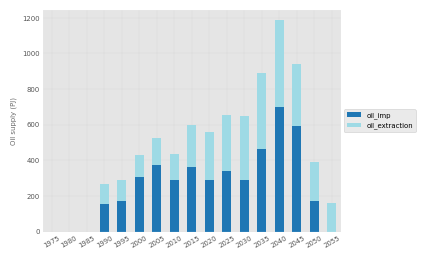

AxesSubplot(0.125,0.11;0.465x0.462)


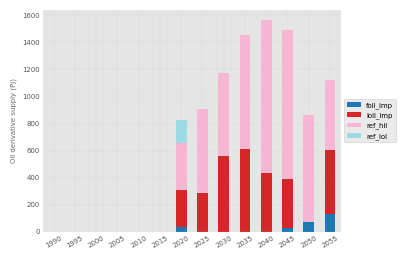

AxesSubplot(0.125,0.11;0.465x0.462)


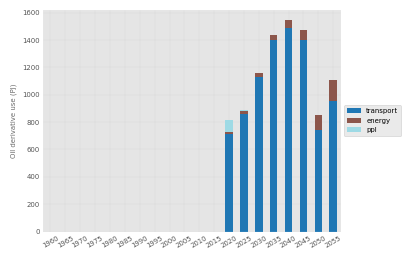

AxesSubplot(0.125,0.11;0.465x0.462)


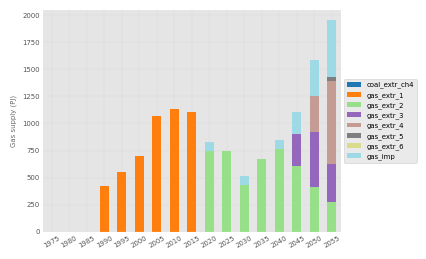

AxesSubplot(0.125,0.11;0.465x0.462)


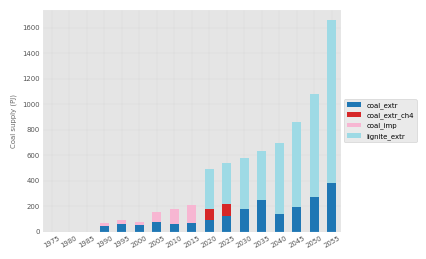

AxesSubplot(0.125,0.11;0.465x0.462)


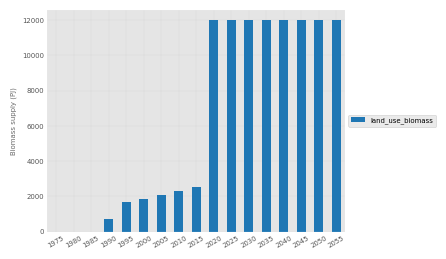

AxesSubplot(0.125,0.11;0.465x0.462)


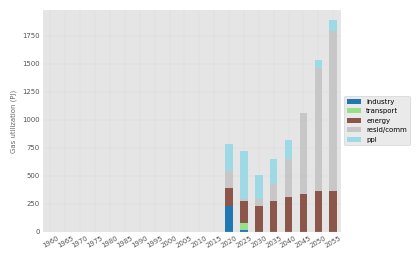

AxesSubplot(0.125,0.11;0.465x0.462)


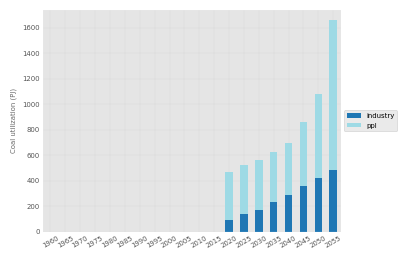

AxesSubplot(0.125,0.11;0.465x0.462)


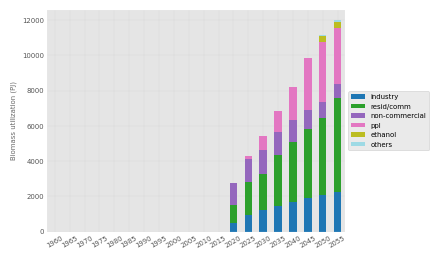

AxesSubplot(0.125,0.11;0.465x0.462)


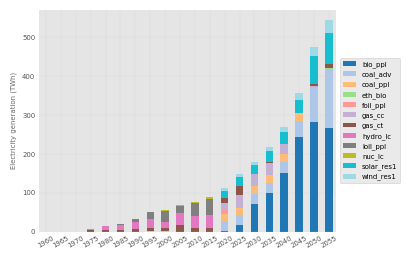

AxesSubplot(0.125,0.11;0.465x0.462)


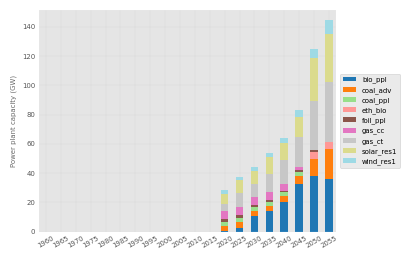

AxesSubplot(0.125,0.11;0.62x0.462)


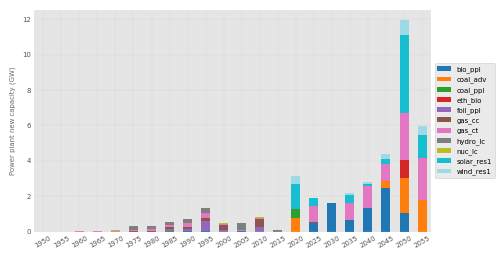

AxesSubplot(0.125,0.11;0.465x0.462)


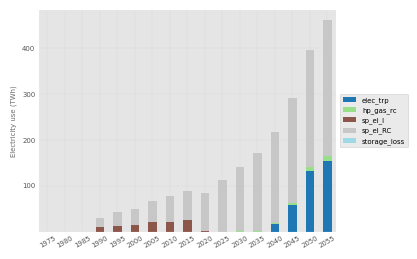

AxesSubplot(0.125,0.11;0.465x0.462)


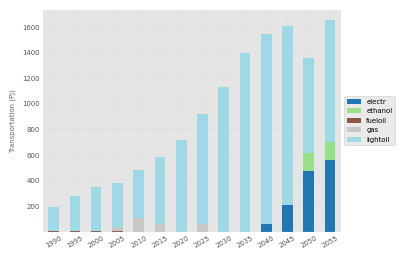

AxesSubplot(0.125,0.11;0.465x0.462)


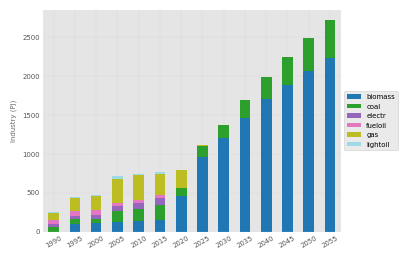

AxesSubplot(0.125,0.11;0.465x0.462)


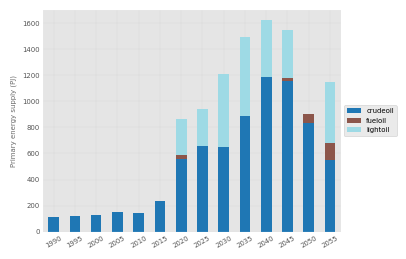

AxesSubplot(0.125,0.11;0.465x0.462)


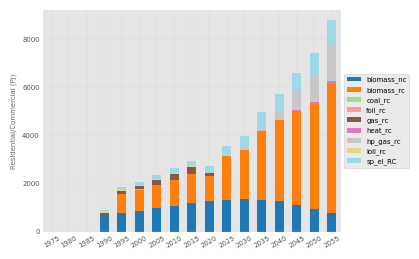

AxesSubplot(0.125,0.11;0.465x0.462)


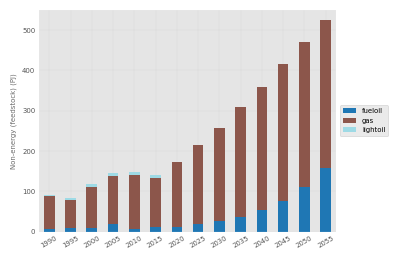

AxesSubplot(0.125,0.11;0.465x0.462)


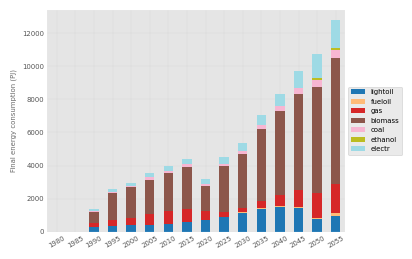

AxesSubplot(0.125,0.11;0.465x0.462)


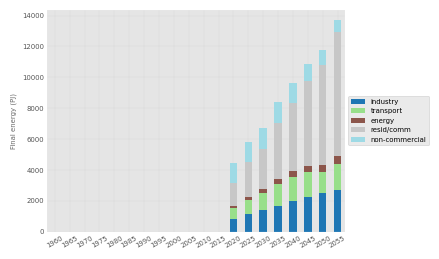

AxesSubplot(0.125,0.11;0.465x0.462)


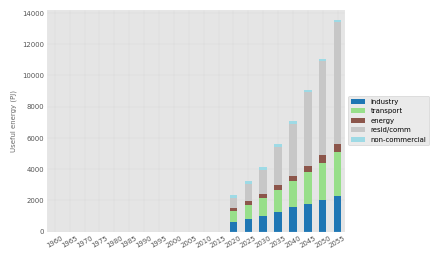

AxesSubplot(0.125,0.11;0.465x0.462)


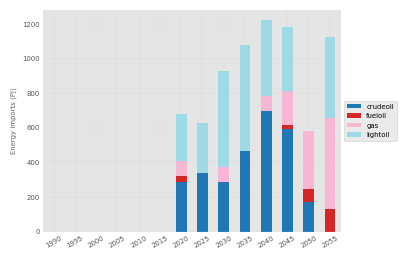

AxesSubplot(0.125,0.11;0.465x0.462)


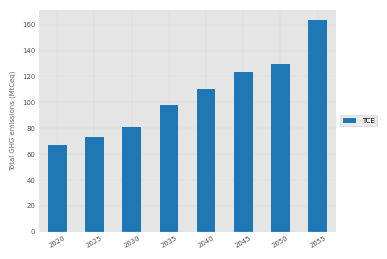

c:\Users\umer.yasin\Desktop\NEST_Pakistan\model\modelFiles\plotter_pakistan.py:496: FutureWarning: save is not part of the public API, usage can give unexpected results and will be removed in a future version
  writer_xls.save()


In [219]:
# Plot and save results
# 1) First run plotter function
alldf = plotter(scenario, caseName, path)

# 2) Then Run Plot function
plot(alldf, caseName, path)

### Report 2

In [ ]:
# #%% Generating reporter
rep = Reporter.from_scenario(scenario)
report = rep.get('message:default') # in fact, only in = input x ACT, out = output x ACT is needed

In [ ]:
from_excel = False
min_year = 2015
max_year = 2060

if from_excel:
    # Read default report
    report_df = pd.read_csv('MESSAGE_NO_example_default_report.csv')
else:
# Or if trying another country model, execute the next 4:
    report_df = report.timeseries()
    report_df.reset_index(inplace=True)
    report_df.columns = report_df.columns.astype(str)
    report_df.columns = report_df.columns.str.title()

In [ ]:
# Plotted years
years = scenario.set('year').tolist()
years = [str(x) for x in years if x >= min_year and x <= max_year]

# Create data for Sankey diagrams and plot it using plotly
report_df.fillna(0, inplace = True)

# Convert from GWa to TWh (*8.76)
c = report_df.select_dtypes(include=[np.number]) * 8.76
report_df[c.columns] = c

# Drop not necessary years
report_df.columns = report_df.columns.astype(str)
report_df = report_df.drop(report_df.columns.to_series()['2020': str(min_year)],
                           axis=1)

# Identify input and output variables and its flows (provided within the Reporter: in = input x ACT, out = output x ACT)
in_flows = report_df[report_df['Variable'].str.startswith("in|")]
out_flows = report_df[report_df['Variable'].str.startswith("out|")]
all_flows = out_flows.append(in_flows)

In [ ]:
report_df.to_csv('output/MESSAGE_Pakistan_v1.csv')

In [ ]:
report_df["Variable"] = report_df["Variable"].str.replace('emis', 'Emissions', regex = False)
#report_df["Variable"] = report_df["Variable"].str.replace('in|final|', 'Final Energy|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('out|final|', 'Final Energy|', regex = False)
#report_df["Variable"] = report_df["Variable"].str.replace('in|primary|', 'Primary Energy|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('out|primary|', 'Primary Energy|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('in|renewable|', 'Primary Energy|renewable|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('out|renewable|', 'Primary Energy|renewable|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('total om cost|', 'Total Costs|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('out|useful|', 'Useful Energy|', regex = False)
report_df["Variable"] = report_df["Variable"].str.replace('in|useful|', 'Useful Energy|', regex = False)

In [ ]:
import pyam
import matplotlib.pyplot as plt
import pyam
plotyrs = [2020,2025,2030,2035,2040,2045,2050,2055,2060]
pyam_df = pyam.IamDataFrame(report_df)
pdf = pyam_df.copy()

In [ ]:

biomass = ['Primary Energy|biomass|bio_istig_ccs|M1', 
'Primary Energy|biomass|bio_istig|M1']
#'Primary Energy|biomass|bio_ppl|M1',
#'Primary Energy|biomass|biomass_nc|M1',
#'Primary Energy|biomass|biomass_t_d|M1',
#'Primary Energy|biomass|eth_bio_ccs|M1',
#'Primary Energy|biomass|eth_bio|M1',
#'Primary Energy|biomass|gas_bio|M1',
#'Primary Energy|biomass|h2_bio_ccs|M1',
#'Primary Energy|biomass|h2_bio|M1',
#'Primary Energy|biomass|liq_bio_ccs|M1',
#'Primary Energy|biomass|liq_bio|M1','Primary Energy|biomass|land_use_biomass|M1']

lng = ['Primary Energy|LNG|LNG_bal|M1']

coal = ['Primary Energy|coal|coal_bal|M1',
                      'Primary Energy|coal|coal_exp|M1',
                      'Primary Energy|coal|coal_exp|M1',
                      'Primary Energy|coal|coal_extr_ch4|M1',
                      'Primary Energy|coal|coal_extr|M1',
                      'Primary Energy|coal|lignite_extr|M1']

gas = [#'Primary Energy|gas|gas_bal|M1',
      'Primary Energy|gas|gas_extr_1|M1',
      'Primary Energy|gas|gas_extr_2|M1',
      'Primary Energy|gas|gas_extr_3|M1',
      'Primary Energy|gas|gas_extr_4|M1',
      'Primary Energy|gas|gas_extr_5|M1',
      'Primary Energy|gas|gas_extr_6|M1']
      #'Primary Energy|gas|LNG_prod|M1']
      # 'Primary Energy|LNG|LNG_bal|M1']

oil = [#'Primary Energy|crudeoil|oil_bal|M1',
    'Primary Energy|crudeoil|oil_exp|M1',
     # 'Primary Energy|crudeoil|oil_extr_1_ch4|M1',
        'Primary Energy|crudeoil|oil_extr_1|M1',
       # 'Primary Energy|crudeoil|oil_extr_2_ch4|M1',
        'Primary Energy|crudeoil|oil_extr_2|M1',
      #  'Primary Energy|crudeoil|oil_extr_3_ch4|M1',
        'Primary Energy|crudeoil|oil_extr_3|M1',
        #'Primary Energy|crudeoil|oil_extr_4_ch4|M1',
        'Primary Energy|crudeoil|oil_extr_4|M1',
        'Primary Energy|crudeoil|oil_extr_5|M1',
        'Primary Energy|crudeoil|oil_extr_6|M1',
        'Primary Energy|crudeoil|oil_extr_7|M1']

hydro = ['Primary Energy|renewable|hydro|hydro_hc|M1',  'Primary Energy|renewable|hydro|hydro_lc|M1']

biomass_renew = ['Primary Energy|renewable|biomass|bio_extr_a|M1',
                'Primary Energy|renewable|biomass|bio_extr_b|M1',
                'Primary Energy|renewable|biomass|bio_extr_c|M1',
                'Primary Energy|renewable|biomass|bio_extr_d|M1',
                'Primary Energy|renewable|biomass|bio_extr_e|M1',
                'Primary Energy|renewable|biomass|bio_extr_f|M1',
                'Primary Energy|renewable|biomass|bio_extr_g|M1']

solar = ['Primary Energy|renewable|solar_pv|solar_pv_ppl|M1' , 
         'Primary Energy|renewable|solar_th|solar_th_ppl|M1']


wind = ['Primary Energy|renewable|wind|wind_ppf|M1', 'Primary Energy|renewable|wind|wind_ppl|M1']

lh2 = ['Primary Energy|lh2|lh2_bal|M1', 'Primary Energy|lh2|lh2_exp|M1']

ethanol = ['Primary Energy|methanol|meth_bal|M1',  'Primary Energy|methanol|meth_exp|M1']

methanol = ['Primary Energy|ethanol|eth_bal|M1', 'Primary Energy|ethanol|eth_exp|M1']

In [ ]:
pdf = pyam_df.copy()

In [ ]:
pdf

In [ ]:
pdf.aggregate(
    "Primary Energy|coal",
    components=coal,
    append=True
)


pdf.aggregate(
    "Primary Energy|renewable|solar",
    components=solar,
    append=True
)

pdf.aggregate(
    "Primary Energy|renewable|hydro",
    components=hydro,
    append=True
)

pdf.aggregate(
    "Primary Energy|ethanol",
    components=ethanol,
    append=True
)
pdf.aggregate(
    "Primary Energy|methanol",
    components=methanol,
    append=True
)
pdf.aggregate(
    "Primary Energy|Liq. Hydrogen",
    components=lh2,
    append=True
)
pdf.aggregate(
    "Primary Energy|renewable|wind",
    components=wind,
    append=True
)

pdf.aggregate(
    "Primary Energy|renewable|biomass",
    components= biomass_renew,
    append=True
)


pdf.aggregate(
    "Primary Energy|biomass",
    components= biomass,
    append=True
)

pdf.aggregate(
    "Primary Energy|oil",
    components=oil,
    append=True
)

pdf.aggregate(
    "Primary Energy|gas",
    components=gas,
    append=True
)

pdf.aggregate(
    "Primary Energy|LNG",
    components=lng,
    append=True
)

In [ ]:
pdf.filter(variable = 'Primary Energy|gas').timeseries()

In [ ]:
data = pdf.filter( variable=["Primary Energy|renewable|solar",
                                            #"Primary Energy|LNG",
                                            "Primary Energy|gas",
                                            "Primary Energy|oil",
                                            "Primary Energy|biomass",
                                            "Primary Energy|renewable|wind",
                                            "Primary Energy|Liq. Hydrogen",
                                            "Primary Energy|methanol",
                                            "Primary Energy|ethanol",
                                            "Primary Energy|renewable|hydro",
                                            "Primary Energy|renewable|biomass",
                                            "Primary Energy|methanol",
                                           "Primary Energy|coal"],
              year = plotyrs)

data.plot.stack(title = 'Primary Energy by fuel - Baseline Scenario')
plt.legend(loc=1)
plt.tight_layout()
plt.show()

In [ ]:
i_feed = ['Useful Energy|i_feed|ethanol_fs|M1', 'Useful Energy|i_feed|gas_fs|M1',
         'Useful Energy|i_feed|loil_fs|M1', 'Useful Energy|i_feed|methanol_fs|M1']

transport = ['Useful Energy|transport|coal_trp|M1',
            'Useful Energy|transport|elec_trp|M1',
            'Useful Energy|transport|eth_fc_trp|M1',
            'Useful Energy|transport|eth_ic_trp|M1',
            'Useful Energy|transport|foil_trp|M1',
            'Useful Energy|transport|gas_trp|M1',
            'Useful Energy|transport|h2_fc_trp|M1',
            'Useful Energy|transport|loil_trp|M1',
            'Useful Energy|transport|meth_fc_trp|M1',
            'Useful Energy|transport|meth_ic_trp|M1']


i_spec = ['Useful Energy|i_spec|h2_fc_I|M1',
          'Useful Energy|i_spec|sp_coal_I|M1',
          'Useful Energy|i_spec|sp_el_I|M1',
          'Useful Energy|i_spec|sp_eth_I|M1',
          'Useful Energy|i_spec|sp_liq_I|M1',
          'Useful Energy|i_spec|sp_meth_I|M1']

i_therm =   ['Useful Energy|i_therm|biomass_i|M1',
            'Useful Energy|i_therm|coal_i|M1',
            'Useful Energy|i_therm|elec_i|M1',
            'Useful Energy|i_therm|eth_i|M1',
            'Useful Energy|i_therm|foil_i|M1',
            'Useful Energy|i_therm|gas_i|M1',
            'Useful Energy|i_therm|h2_fc_I|M1',
            'Useful Energy|i_therm|h2_i|M1',
            'Useful Energy|i_therm|heat_i|M1',
            'Useful Energy|i_therm|hp_el_i|M1',
            'Useful Energy|i_therm|hp_gas_i|M1',
            'Useful Energy|i_therm|loil_i|M1',
            'Useful Energy|i_therm|meth_i|M1',
            'Useful Energy|i_therm|solar_i|M1']
rc_spec = ['Useful Energy|rc_spec|h2_fc_RC|M1',
          'Useful Energy|rc_spec|sp_el_RC|M1']

rc_therm = ['Useful Energy|rc_therm|biomass_rc|M1',
            'Useful Energy|rc_therm|coal_rc|M1',
            'Useful Energy|rc_therm|eth_rc|M1',
            'Useful Energy|rc_therm|foil_rc|M1',
            'Useful Energy|rc_therm|gas_rc|M1',
            'Useful Energy|rc_therm|h2_fc_RC|M1',
            'Useful Energy|rc_therm|h2_rc|M1',
            'Useful Energy|rc_therm|heat_rc|M1',
            'Useful Energy|rc_therm|hp_el_rc|M1',
            'Useful Energy|rc_therm|hp_gas_rc|M1',
            'Useful Energy|rc_therm|loil_rc|M1',
            'Useful Energy|rc_therm|meth_rc|M1',
            'Useful Energy|rc_therm|solar_rc|M1']

biom = ['Useful Energy|non-comm|biomass_nc|M1']

In [ ]:
df_useful = pyam_df.copy()
# df_useful.aggregate(
#     "Useful Energy|non-Commercial biomass",
#     components=biom,
#     append=True
# )

df_useful.aggregate(
    "Useful Energy|residential/commercial thermal",
    components=rc_therm,
    append=True
)

df_useful.aggregate(
    "Useful Energy|residential/commercial specific",
    components=rc_spec,
    append=True
)

df_useful.aggregate(
    "Useful Energy|industrial thermal",
    components=i_therm,
    append=True
)

df_useful.aggregate(
    "Useful Energy|industrial specific",
    components=i_spec,
    append=True
)

df_useful.aggregate(
    "Useful Energy|industrial feedstock",
    components=i_feed,
    append=True
)

df_useful.aggregate(
    "Useful Energy|transport",
    components=i_therm,
    append=True
)


In [ ]:
df_useful

In [ ]:
df_useful.filter(variable = 'Useful Energy|transport').timeseries()

In [ ]:
data = df_useful.filter(scenario = 'baseline_xlsx', variable=[
    "Useful Energy|non-Commercial biomass", # It's empty 
    "Useful Energy|residential/commercial thermal",
    "Useful Energy|residential/commercial specific",
    "Useful Energy|industrial thermal",
    "Useful Energy|industrial specific",
    "Useful Energy|industrial feedstock",
    "Useful Energy|transport"],
              year = plotyrs)


data.plot.stack(title = 'Demands by sector')
plt.legend(loc=1)
plt.tight_layout()
plt.show()

In [ ]:
cement = ['Emissions|CO2|cement_CO2|M1']
coal = ['Emissions|CO2|coal_extr_ch4|M1',
        'Emissions|CO2|coal_extr|M1',
        'Emissions|CO2|coal_imp|M1']
foil = ['Emissions|CO2|foil_imp|M1']
gas = ['Emissions|CO2|gas_extr_1|M1',
        'Emissions|CO2|gas_extr_2|M1',
        'Emissions|CO2|gas_extr_3|M1',
        'Emissions|CO2|gas_extr_4|M1',
        'Emissions|CO2|gas_extr_5|M1',
        'Emissions|CO2|gas_extr_6|M1'
        ]
lignite = ['Emissions|CO2|lignite_extr|M1']
loil = ['Emissions|CO2|loil_imp|M1']
meth_ccs = ['Emissions|CO2|meth_coal_ccs|M1']
oil = ['Emissions|CO2|oil_extr_1_ch4|M1',
    'Emissions|CO2|oil_extr_1|M1',
    'Emissions|CO2|oil_extr_2_ch4|M1',
    'Emissions|CO2|oil_extr_2|M1',
    'Emissions|CO2|oil_extr_3_ch4|M1',
    'Emissions|CO2|oil_extr_3|M1',
    'Emissions|CO2|oil_extr_4_ch4|M1',
    'Emissions|CO2|oil_extr_4|M1',
    'Emissions|CO2|oil_extr_5|M1',
    'Emissions|CO2|oil_extr_6|M1',
    'Emissions|CO2|oil_extr_7|M1']

oil_trade = ['Emissions|CO2|foil_imp|M1',
             'Emissions|CO2|loil_exp|M1',
            'Emissions|CO2|loil_imp|M1',
             'Emissions|CO2|oil_imp|M1']
       
gas_trade = ['Emissions|CO2|LNG_exp|M1',
            'Emissions|CO2|LNG_imp|M1',
            'Emissions|CO2|gas_imp|M1']
            #'Emissions|CO2|LNG_exp|M1']

In [ ]:
df_emis_b = pyam_df.filter(variable = 'Emissions|CO2|*',year = plotyrs)

In [ ]:
df_emis_b

In [ ]:
df_emis_b.to_csv('emissions.csv')

In [ ]:
df_emis = pyam_df.copy()


df_emis.aggregate(
    "Emissions|CO2|gas",
    components=gas,
    append=True
)

df_emis.aggregate(
    "Emissions|CO2|oil",
    components=oil,
    append=True
)

df_emis.aggregate(
    "Emissions|CO2|coal",
    components=coal,
    append=True
)

df_emis.aggregate(
    "Emissions|CO2|cement",
    components=cement,
    append=True
)

df_emis.aggregate(
    "Emissions|CO2|oil trade",
    components=oil_trade,
    append=True
)

df_emis.aggregate(
    "Emissions|CO2|gas trade",
    components=gas_trade,
    append=True
)

In [ ]:
data = df_emis.filter(scenario = 'baseline_xlsx', variable=
    ["Emissions|CO2|gas",
    "Emissions|CO2|oil",
    "Emissions|CO2|coal",
    "Emissions|CO2|cement",
    "Emissions|CO2|oil trade",
    "Emissions|CO2|gas trade"],
              year = plotyrs)

data.plot.stack(title = 'CO2 Emissions - Baseline Scenario')
plt.legend(loc=1)
plt.tight_layout()
plt.show()

In [ ]:
df_emis.aggregate('Emissions|*').timeseries()

In [ ]:

coal = ['Total Costs|coal_adv',
        'Total Costs|coal_adv_ccs',
        'Total Costs|coal_bal',
        'Total Costs|coal_exp',
        'Total Costs|coal_extr',
        'Total Costs|coal_extr_ch4',
        'Total Costs|coal_gas',
        'Total Costs|coal_hpl',
        'Total Costs|coal_i',
        'Total Costs|coal_imp',
        'Total Costs|coal_ppl',
        'Total Costs|coal_ppl_u',
        'Total Costs|coal_rc',
        'Total Costs|coal_ppl',
        'Total Costs|coal_ppl_u',
       'Total Costs|coal_t_d',
       'Total Costs|syn_liq',
        'Total Costs|meth_coal',
       'Total Costs|lignite_extr']
biomass = ['bio_hpl', 'bio_ppl',
          'Total Costs|liq_bio']


elec = ['Total Costs|elec_exp',
        'Total Costs|elec_i',
        'Total Costs|elec_imp',
        'Total Costs|elec_t_d',
        'Total Costs|elec_trp']

oil = ['Total Costs|foil_i',
    'Total Costs|foil_imp',
    'Total Costs|foil_ppl',
    'Total Costs|oil_extr_1'
    'Total Costs|oil_extr_1_ch4'
    'Total Costs|oil_extr_2',
    'Total Costs|oil_extr_3',
    'Total Costs|oil_extr_4',
    'Total Costs|oil_extr_5',
    'Total Costs|oil_extr_6',
    'Total Costs|oil_extr_7',
    'Total Costs|oil_extr_2_ch4',
    'Total Costs|oil_extr_3_ch4',
    'Total Costs|loil_cc',
    'Total Costs|loil_ppl']
gas = ['Total Costs|gas_bal',
    'Total Costs|gas_bio',
    'Total Costs|gas_cc',
    'Total Costs|gas_cc_ccs',
    'Total Costs|gas_ct',
    'Total Costs|gas_extr_1',
    'Total Costs|gas_extr_2',
    'Total Costs|gas_extr_3',
    'Total Costs|gas_extr_4',
    'Total Costs|gas_extr_5',
    'Total Costs|gas_extr_6',
    'Total Costs|gas_extr_mpen',
    'Total Costs|gas_fs',
    'Total Costs|gas_hpl',
    'Total Costs|gas_i',
    'Total Costs|gas_imp',
    'Total Costs|gas_ppl',
    'Total Costs|gas_rc',
    'Total Costs|gas_t_d',
    'Total Costs|gas_t_d_ch4',
    'Total Costs|gas_trp',
      'Total Costs|igcc']

geo_ppl = ['Total Costs|geo_hpl','Total Costs|geo_ppl']

solar = ['Total Costs|solar_i',
        'Total Costs|solar_pv_ppl',
        'Total Costs|solar_rc',
        'Total Costs|solar_th_ppl']

wind = ['Total Costs|wind_curtailment1',
'Total Costs|wind_curtailment2',
'Total Costs|wind_curtailment3',
'Total Costs|wind_ppf',
'Total Costs|wind_ppl']

hydro = ['Total Costs|hydro_hc',
'Total Costs|hydro_lc']

nuclear = ['Total Costs|nuc_lc']


In [ ]:
df_cost = pyam_df.copy()


df_cost.aggregate(
    "Total Costs|coal",
    components=coal,
    append=True
)

df_cost.aggregate(
    "Total Costs|biomass",
    components=biomass,
    append=True
)

df_cost.aggregate(
    "Total Costs|electricity",
    components=elec,
    append=True
)

df_cost.aggregate(
    "Total Costs|oil",
    components=biomass,
    append=True
)

df_cost.aggregate(
    "Total Costs|gas",
    components=gas,
    append=True
)

df_cost.aggregate(
    "Total Costs|geothermal",
    components=geo_ppl,
    append=True
)

df_cost.aggregate(
    "Total Costs|solar",
    components=solar,
    append=True
)

df_cost.aggregate(
    "Total Costs|wind",
    components=wind,
    append=True
)

df_cost.aggregate(
    "Total Costs|hydro",
    components=hydro,
    append=True
)
df_cost.aggregate(
    "Total Costs|nuclear",
    components=nuclear,
    append=True
)

In [ ]:
data = df_cost.filter(scenario = 'baseline_xlsx', variable=
    ["Total Costs|coal","Total Costs|biomass",
    "Total Costs|electricity",
    "Total Costs|oil",
    "Total Costs|gas",
    "Total Costs|geothermal",
    "Total Costs|solar",
    "Total Costs|wind",
    "Total Costs|hydro",
    "Total Costs|nuclear"],
              year = plotyrs)

data.plot.stack(title = 'Total (Operational+ Investment) Costs - Baseline')
plt.legend(loc=1)
plt.tight_layout()
plt.show()


In [ ]:
# closed the database connection, you can reopen it using "mp.open_db()"
mp.close_db()